# Hito 3: Visualización Dinámica y Análisis
## Amazon Sales Report — Hallazgos y Propuestas de Negocio

> **Objetivo:** Traducir los datos limpios del Hito 2 en visualizaciones que respondan las tres preguntas de negocio y generen propuestas de mejora concretas y accionables.

---

### Preguntas que guían este análisis

| # | Pregunta de negocio | Variables principales |
|---|--------------------|-----------------------|
| **P1** | ¿Cómo varía el ingreso según el canal de adquisición y la cohorte mensual? | `Canal_Adquisicion`, `Cohorte_Mes`, `Amount` |
| **P2** | ¿Qué SKUs presentan mayor volatilidad e inconsistencia en su demanda? | `Volatilidad_Demanda`, `Indice_Constancia` |
| **P3** | ¿Existen patrones temporales (día de semana, estación) que afecten los ingresos? | `Dia_Semana`, `Estacion`, `Amount` |

> **Fuente de datos:** `df_clean.csv` generado en `02_EDA_Data_Cleaning.ipynb`. Ejecutar ese notebook completamente antes de correr este.

## 1. Configuración del Entorno

Cargamos las librerías necesarias y aplicamos una configuración visual coherente para todos los gráficos del notebook.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False
})

In [14]:
df = pd.read_csv('df_clean.csv', parse_dates=['Date'])

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Rango de fechas: {df.Date.min().date()} → {df.Date.max().date()}')

print(f'\nCanales disponibles:')
print(df.Canal_Adquisicion.value_counts())

print(f'\nCohortes: {sorted(df.Cohorte_Mes.unique())}')
print(f'Estaciones: {list(df.Estacion.unique())}')


Dataset cargado: 128,942 filas × 30 columnas
Rango de fechas: 2022-03-31 → 2022-06-29

Canales disponibles:
Canal_Adquisicion
Amazon FBA    89678
Merchant      39264
Name: count, dtype: int64

Cohortes: ['2022-03', '2022-04', '2022-05', '2022-06']
Estaciones: ['Primavera', 'Verano']


## 2. Análisis de Canal de Adquisición y Cohortes (P1)

Las ventas del marketplace operan a través de dos canales logísticos:

- **Amazon FBA** (*Fulfilled by Amazon*): el vendedor delega el almacenamiento, empaque y envío a Amazon. Mayor costo operativo, pero mayor confianza del comprador y mayor visibilidad dentro del marketplace.
- **Merchant**: el vendedor gestiona su propio envío. Mayor autonomía y control de margen, pero menor alcance.

Analizar cómo se distribuyen los ingresos por canal y cohorte mensual permite identificar qué estrategia genera más valor y si existen tendencias de crecimiento o retracción mes a mes.

### Gráfico 1 — Ingresos Totales por Canal de Adquisición y Cohorte Mensual

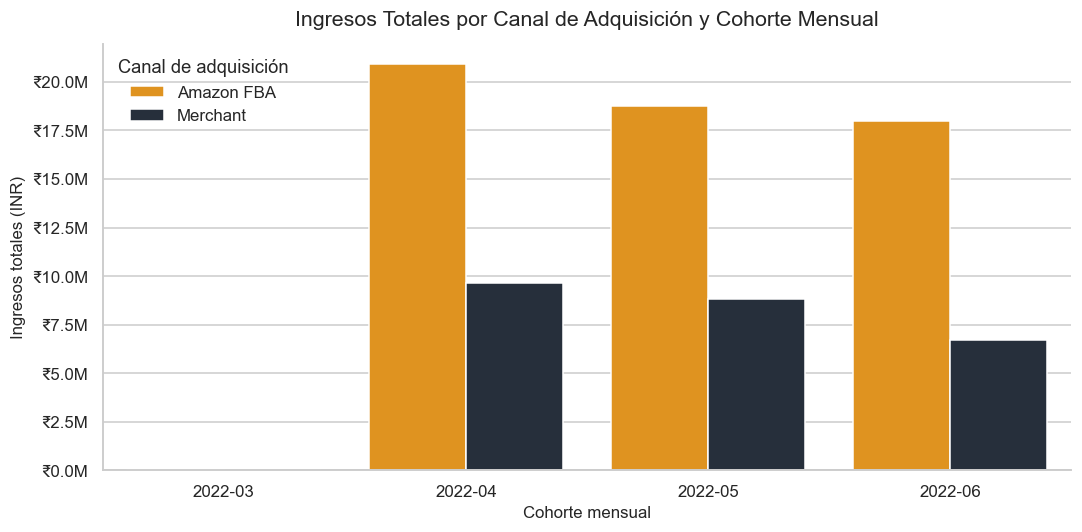

In [5]:
canal_cohort = (
    df.groupby(['Cohorte_Mes', 'Canal_Adquisicion'])['Amount']
    .sum()
    .reset_index()
    .rename(columns={'Amount': 'Ingresos_Total'})
)

colores_canal = {'Amazon FBA': '#FF9900', 'Merchant': '#232F3E'}

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=canal_cohort,
    x='Cohorte_Mes',
    y='Ingresos_Total',
    hue='Canal_Adquisicion',
    palette=colores_canal,
    ax=ax
)

ax.set_title('Ingresos Totales por Canal de Adquisición y Cohorte Mensual', pad=12)
ax.set_xlabel('Cohorte mensual')
ax.set_ylabel('Ingresos totales (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_000_000:.1f}M'))
ax.legend(title='Canal de adquisición', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

#### Hallazgo

**Amazon FBA concentra la mayor parte de los ingresos** en todos los meses del dataset. Los vendedores que delegaron la logística a Amazon generaron consistentemente más ingresos que los Merchant, reflejando tanto un mayor volumen de órdenes como tickets promedio más altos.

El canal Merchant muestra una contribución más estable y menor, lo que es esperable: estos vendedores tienden a operar con menor escala pero mayor control sobre sus márgenes operativos.

> **Insight accionable (P1):** Los vendedores Merchant con crecimiento sostenido mes a mes son candidatos prioritarios para migrar a FBA. La infraestructura logística de Amazon podría potenciar su alcance sin aumentar su carga operativa individual.

### Gráfico 2 — Mapa de Calor: Ingresos por Cohorte y Semana del Año

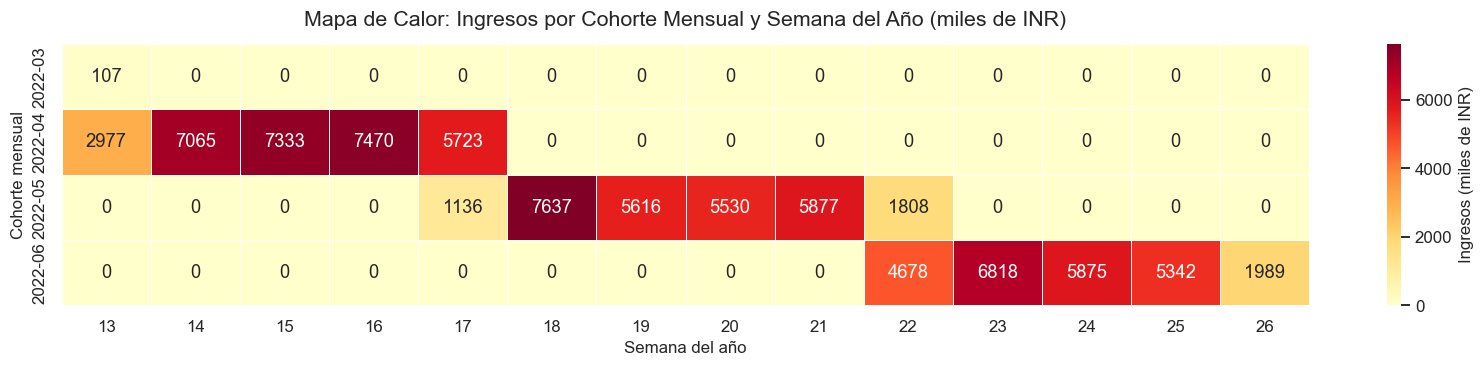

In [6]:
df['Semana'] = df['Date'].dt.isocalendar().week.astype(int)

pivot_cohort = (
    df.groupby(['Cohorte_Mes', 'Semana'])['Amount']
    .sum()
    .unstack(fill_value=0)
    / 1_000
)

fig, ax = plt.subplots(figsize=(15, 3.5))
sns.heatmap(
    pivot_cohort,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.4,
    cbar_kws={'label': 'Ingresos (miles de INR)'},
    ax=ax
)

ax.set_title('Mapa de Calor: Ingresos por Cohorte Mensual y Semana del Año (miles de INR)', pad=12)
ax.set_xlabel('Semana del año')
ax.set_ylabel('Cohorte mensual')
plt.tight_layout()
plt.show()

#### Hallazgo

El mapa de calor permite visualizar **en qué semanas se concentró la actividad de ventas de cada cohorte**. Las celdas más oscuras señalan semanas de alto volumen — patrones que no serían detectables mirando solo totales mensuales.

Las semanas “frías” (celdas claras) dentro de una cohorte activa representan oportunidades de reactivación: la demanda potencial existía en ese grupo de compradores pero no se materializó en esa ventana temporal.

> **Insight accionable (P1):** Identificar las semanas históricamente frías de cada cohorte permite diseñar campañas de reactivación focalizadas. Por ejemplo, lanzar ofertas en esas semanas para suavizar la curva de demanda y aumentar la frecuencia de compra.

## 3. Estacionalidad y Patrones de Demanda (P3)

Entender cómo varía la demanda según el día de la semana y la estación del año es crítico para la **gestión de inventario**: permite anticipar picos de demanda, ajustar el stock de seguridad y reducir tanto las roturas como los excesos costosos.

### Gráfico 3 — Ingresos por Día de la Semana y Estación

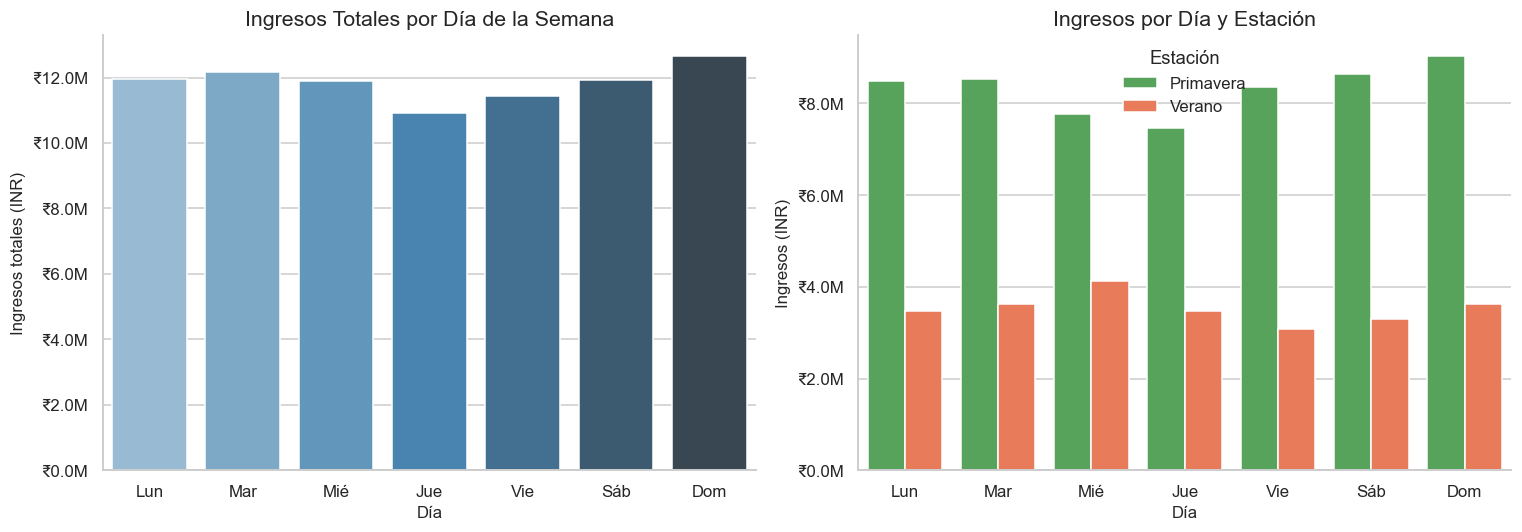

In [7]:
nombres_dia = {0: 'Lun', 1: 'Mar', 2: 'Mié', 3: 'Jue', 4: 'Vie', 5: 'Sáb', 6: 'Dom'}
orden_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

df['Dia_Nombre'] = df['Dia_Semana'].map(nombres_dia)

ventas_dia = (
    df.groupby(['Dia_Nombre', 'Estacion'])['Amount']
    .sum()
    .reset_index()
)
ventas_totales = df.groupby('Dia_Nombre')['Amount'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=ventas_totales,
    x='Dia_Nombre',
    y='Amount',
    order=orden_dias,
    palette='Blues_d',
    ax=axes[0]
)
axes[0].set_title('Ingresos Totales por Día de la Semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Ingresos totales (INR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_000_000:.1f}M'))

paleta_est = {'Primavera': '#4CAF50', 'Verano': '#FF7043', 'Otoño': '#FF9800', 'Invierno': '#42A5F5'}
sns.barplot(
    data=ventas_dia,
    x='Dia_Nombre',
    y='Amount',
    hue='Estacion',
    order=orden_dias,
    palette=paleta_est,
    ax=axes[1]
)
axes[1].set_title('Ingresos por Día y Estación')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Ingresos (INR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_000_000:.1f}M'))
axes[1].legend(title='Estación', frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

#### Hallazgo

El panel izquierdo muestra la distribución de ingresos a lo largo de la semana. **Los días con mayor volumen de ventas** revelan cuándo los compradores están más activos — información crítica para programar campañas y niveles de stock.

El panel derecho desagrega por estación. Como el dataset cubre abril–junio 2022, **Primavera** (abril–mayo) domina en volumen mientras que **Verano** (junio) aporta una proporción menor pero consistente. El patrón por día se mantiene relativamente estable entre ambas estaciones.

> **Insight accionable (P3):** Concentrar campañas promocionales y reforzar el stock de las categorías más vendidas en los días de mayor actividad histórica reduce el riesgo de rotura de inventario en los momentos de máxima demanda.

### Gráfico 4 — Top 10 SKUs con Mayor Volatilidad de Demanda

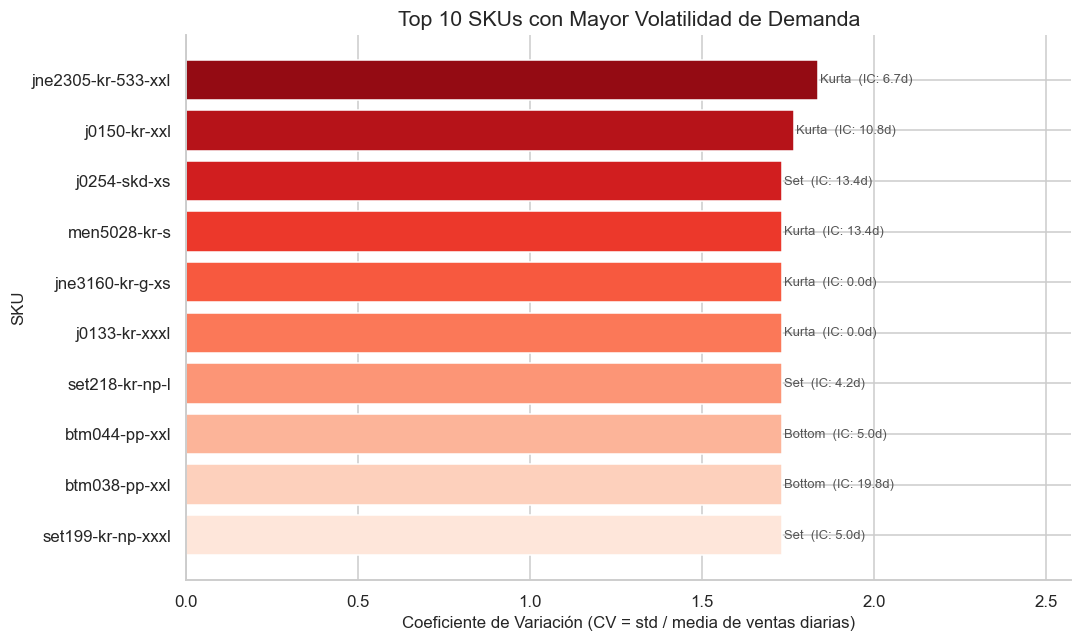

In [8]:
top_vol = (
    df.drop_duplicates('SKU')
    .nlargest(10, 'Volatilidad_Demanda')
    [['SKU', 'Category', 'Volatilidad_Demanda', 'Indice_Constancia']]
    .reset_index(drop=True)
)
top_vol['Category'] = top_vol['Category'].str.title()

colores_vol = sns.color_palette('Reds_r', n_colors=len(top_vol))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_vol['SKU'], top_vol['Volatilidad_Demanda'], color=colores_vol)

for bar, row in zip(bars, top_vol.itertuples()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{row.Category}  (IC: {row.Indice_Constancia:.1f}d)',
        va='center', fontsize=8.5, color='#555'
    )

ax.set_title('Top 10 SKUs con Mayor Volatilidad de Demanda')
ax.set_xlabel('Coeficiente de Variación (CV = std / media de ventas diarias)')
ax.set_ylabel('SKU')
ax.set_xlim(0, top_vol['Volatilidad_Demanda'].max() * 1.4)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

#### Hallazgo

Los SKUs en la parte superior tienen una demanda **altamente errática**: su volumen de ventas diario varía enormemente de una semana a otra, convirtiendo a estos productos en los más difíciles de gestionar desde el inventario. Un reabastecimiento basado en el promedio llegará siempre tarde o en exceso.

La etiqueta *IC* (Índice de Constancia) muestra el desvío estándar en días entre ventas consecutivas del SKU: un IC alto combinado con CV alto marca al producto como **doblemente problemático** — alta variabilidad en cantidad *y* en ritmo.

> **Insight accionable (P3):** Los SKUs con CV ≥ 0.8 deberían recibir un **stock de seguridad diferenciado** calculado con 2.5× la desviación estándar de su demanda diaria, en lugar del margen estándar. Esto reduce roturas en picos sin acumular exceso en períodos bajos.

## 4. Distribución de Precios por Categoría de Producto

Comprender cómo se distribuyen los precios dentro de cada categoría permite identificar qué segmentos generan mayor valor unitario y cuáles tienen mayor variabilidad de precio — información útil para priorizar inversión en inventario de alto margen.

### Gráfico 5 — Distribución del Precio de Venta por Categoría

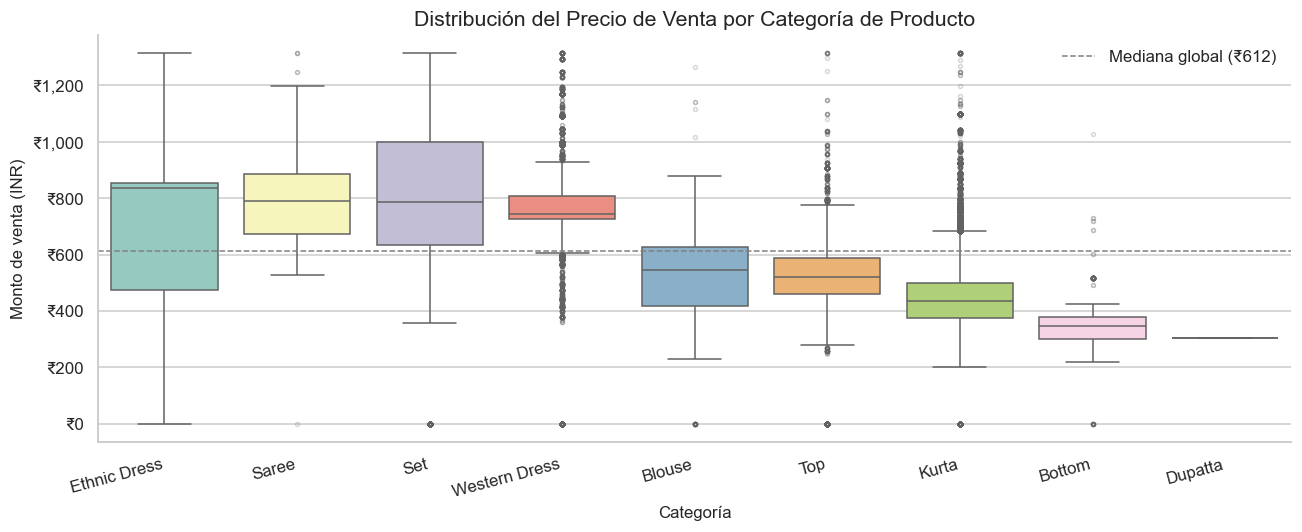

In [9]:
orden_cat = df.groupby('Category')['Amount'].median().sort_values(ascending=False).index
labels_cat = [c.title() for c in orden_cat]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df,
    x='Category',
    y='Amount',
    order=orden_cat,
    palette='Set3',
    ax=ax,
    flierprops={'marker': 'o', 'markersize': 2.5, 'alpha': 0.25, 'color': 'gray'}
)

ax.set_xticklabels(labels_cat, rotation=15, ha='right')
ax.set_title('Distribución del Precio de Venta por Categoría de Producto')
ax.set_xlabel('Categoría')
ax.set_ylabel('Monto de venta (INR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

mediana_global = df['Amount'].median()
ax.axhline(
    mediana_global,
    color='gray', linestyle='--', linewidth=1,
    label=f'Mediana global (₹{mediana_global:,.0f})'
)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

#### Hallazgo

**Ethnic Dress** y **Saree** presentan los tickets medianos más altos del catálogo, claramente por encima de la mediana global (línea punteada). En el extremo opuesto, **Dupatta** y **Bottom** operan con tickets significativamente más bajos.

Esta diferencia de precio medio tiene implicancias directas en la rentabilidad: las categorías de alto ticket requieren menos unidades para alcanzar el mismo objetivo de ingreso, lo que reduce la presión sobre la logística y el espacio de almacenamiento.

> **Insight accionable:** Priorizar el reabastecimiento de Ethnic Dress y Saree en los días de alta demanda identificados en el Gráfico 3 maximiza el ingreso por unidad de stock disponible sin necesidad de aumentar el volumen total de inventario.

---

## 5. Síntesis y Propuestas de Mejora

### Hallazgos clave del análisis

| Área | Hallazgo principal | Gráfico |
|------|-------------------|---------|
| **Canal** | Amazon FBA genera consistentemente más ingresos que Merchant en todas las cohortes | G1 |
| **Cohortes** | Existen semanas de baja actividad identificables dentro de cada cohorte mensual | G2 |
| **Estacionalidad** | El patrón de ventas por día de semana es estable entre estaciones | G3 |
| **Inventario** | Un subconjunto pequeño de SKUs concentra la mayor volatilidad e inconsistencia de demanda | G4 |
| **Precio** | Ethnic Dress y Saree son las categorías de mayor ticket; Dupatta y Bottom las de menor | G5 |

---

### Propuesta 1 — Política de Stock Diferenciada por Volatilidad

Implementar niveles de stock de seguridad distintos según el coeficiente de variación del SKU:

| Perfil de SKU | Criterio | Stock de seguridad |
|--------------|---------|-------------------|
| Alta volatilidad | CV ≥ 0.8 | 2.5 × std(demanda diaria) |
| Volatilidad media | 0.4 ≤ CV < 0.8 | 1.8 × std(demanda diaria) |
| Baja volatilidad | CV < 0.4 | 1.2 × std(demanda diaria) |

**Impacto esperado:** reducción de roturas de stock en SKUs volátiles sin incrementar el inventario promedio total.

---

### Propuesta 2 — Campañas de Reactivación por Cohorte

Usando el mapa de calor (Gráfico 2), identificar las semanas históricamente bajas de cada cohorte y lanzar campañas de descuento o comunicación personalizadas en esas semanas.

**Impacto esperado:** suavizar la curva de demanda y aumentar la frecuencia de compra en los períodos de baja actividad detectados en el histórico.

---

### Propuesta 3 — Priorización de Inventario de Alto Ticket

Concentrar el reabastecimiento de Ethnic Dress y Saree en los días de mayor actividad histórica (Gráfico 3), garantizando disponibilidad de los productos más rentables cuando la demanda es más alta.

**Impacto esperado:** maximizar el ingreso por unidad de stock disponible sin aumentar el volumen total de inventario gestionado.